# Rename-proof logic consensus and error-type tests: demo of `method.py`

This notebook walks through the **orchestrator and output builder** (`method.py`) of an experiment on **gold-free metrics for NL→FOL output quality**. These metrics score a candidate first-order-logic formula for a sentence without a gold formula.

**What the experiment does**
* **Part A: PEER_HYB consensus.** A candidate formula *agrees* with a peer formula (the same sentence formalised by another model family) if either of two maps gives a z3-verified equivalence: the name-similarity **ALIGN** map, or the name-free **NF-anchored** map. The score is `c_score = 1 − share of agreeing peers`, so **higher means more likely an error**. A rule, fixed before labels were joined, had to choose between HYB and NF-anchored. **Neither passed the rename false-alarm criterion**, so nothing was frozen. The read uses ALIGN.
* **Part B: PERTURB suite.** 27 metrics were scored on 4,234 typed mutants of gold formulas (ADD, DROP, NEG, QUANT, SWAP, REV, …), 868 meaning-preserving controls and 300 unmutated bases. The metrics include consensus variants, text-anchored scores, local LLM judges, round-trip NLI, self-consistency and the user's pilot structural metrics.
* **Parts C and D** cover error-type identification and a reusable library (`src/consensus_lib.py`).

**What this notebook runs.** `method.py` itself has two parts. `run()` chains 13 stages: z3 pair scoring, pre-registration freezes, analyses, GPU local judges and OpenRouter calls. `build_output()` joins all stage results into one `method_out.json` with oriented per-row scores for 4 datasets. The full pipeline needs a GPU, API keys and hours, so the **stage runner is shown but not executed**. The notebook writes a **curated subset of the real stage outputs** into a small local workspace and runs **`build_output()` unchanged** on it. It then recomputes key statistics on the demo rows: within-base AUROC per metric on PERTURB, and consensus against labels on dataset E.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# ---- original import block of method.py (as-is)
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys
from pathlib import Path

from loguru import logger

# ---- additional imports for the notebook (C-shim for src/an_common.py, results tables, plots)
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

## Load the demo data

`mini_demo_data.json` holds real rows taken from the artifact's stage outputs. The key is the original relative path; `build_output()` reads each file by that path.
* `results/`: `selection.json` (the Part A outcome), `analysis_perturb.json` (metric list plus full-run summary), the texts of both pre-registration files, and per-row score tables: `per_item_hyb_E.jsonl`, `perturb_scores.jsonl` and `per_item_screen_hyb.jsonl`.
* `data/`: the blinded dataset-E rows (text plus candidate formula), the PERTURB rows (text plus mutant formula), and screen items, rewrites and probes with labels.

It contains 100 rows in total: **4 PERTURB bases with all 73 of their mutants, controls and base rows**, **15 dataset-E candidates** from 2 sentences written by 8 LLM families, and **12 screen / rewrite / probe rows**.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_e4aqYfQhdCkX/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print({k: (len(v) if isinstance(v, (list, dict)) else "text") for k, v in {**data["results"], **data["data"]}.items()})

Curated subset of the inputs of method.py build_output(): 4 PERTURB bases with all their mutants/controls, 2 dataset-E sentences with their real generator candidates, and a few screen items / rewrites / probes.
{'selection.json': 10, 'analysis_perturb.json': 4, 'prereg_hyb.json__text': 'text', 'prereg_perturb.json__text': 'text', 'per_item_hyb_E.jsonl': 15, 'perturb_scores.jsonl': 73, 'per_item_screen_hyb.jsonl': 12, 'exp5/E_blind.jsonl': 15, 'perturb_rows.jsonl': 69, 'screen/screen_adjudicated_labels.json': 4, 'invariance_items.json': 5, 'screen/screen_items.json': 6, 'exp5/screen_probes.json': 3}


## Configuration

The original script has no numeric hyper-parameters. Its inputs are whole result files, and each stage is a separate script with its own settings, such as the z3 timeout of 2000 ms, k = 5 bijections and a 30 s pair cap. The tunable part of this demo is **how many rows of each table go to `build_output()`**. The demo data holds 4 PERTURB bases, 15 E rows and 12 screen rows. The original full run used 300 bases (5,402 PERTURB rows), 8,507 E rows and 1,870 screen rows.

`RUN_STAGES` controls whether the original 13-stage pipeline runs. It stays `False`: the stages need the full repository, a GPU and OpenRouter keys.

In [5]:
N_PERTURB_BASES = 4   # PERTURB bases to keep (all their mutants/controls follow); demo max 4, original 300
N_E_ROWS = 15         # dataset-E candidate rows; demo max 15, original 8507
N_SCREEN_ROWS = 12    # screen items + exp-D rewrites + probes; demo max 12, original 1870
RUN_STAGES = False    # True would call the 13 original pipeline stages (needs the full repo, a GPU and API keys)

## Setup: paths and logging (from `method.py`)

These are the original module-level settings. The one change is that `ROOT` is a local `demo_workspace/` folder rather than `Path(__file__).resolve().parent`, because a notebook has no `__file__`. The folder is created so that the log sink has somewhere to write.

In [6]:
ROOT = Path("demo_workspace").resolve()   # original: Path(__file__).resolve().parent
(ROOT / "logs").mkdir(parents=True, exist_ok=True)
RES = ROOT / "results"
PY = str(ROOT / ".venv" / "bin" / "python")
sys.path.insert(0, str(ROOT / "src"))

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

2

## The stage pipeline (`run`, shown but not executed)

`method.py run` executes the stages below in order, each as its own script:
| stage | what it does |
|---|---|
| `score` | z3 pair engine: ALIGN / NF-anchored / HYB verdicts for every candidate–peer pair (dataset E and screen) |
| `gate` | regression gate against the frozen columns of the earlier experiment (exp 5) |
| `freeze_a` | writes `prereg_hyb.json` and its sha256 **before any label join** |
| `part_a` | screen thresholds, rename false alarms, over-alignment, the HYB/NF **selection** and E AUROCs |
| `calib`, `api`, `cpu_b`, `gpu_b`, `s4` | score all Part B metrics on PERTURB (flash-lite judge via OpenRouter, nf4 local judges and round-trip NLI on GPU, S4 stack) |
| `freeze_b`, `part_b` | pre-register the PERTURB thresholds, then compute sensitivity per operator × polarity, invariance and trade-off |
| `part_c`, `tests` | error-type identification; library unit tests |

Stages that have a `DONE_MARK` file are skipped once it exists, so frozen pre-registration files are never overwritten. The code is copied unchanged. Only the call is guarded by `RUN_STAGES`.

In [7]:
STAGES = [
    ("score", [[PY, "src/run_scoring.py", "E", "--stage", "all"], [PY, "src/run_scoring.py", "screen", "--stage", "all"]]),
    ("gate", [[PY, "src/gate_check.py"]]),
    ("freeze_a", [[PY, "src/freeze_prereg_hyb.py"]]),
    ("part_a", [[PY, "src/analyse_hyb.py"]]),
    ("calib", [[PY, "src/prep_calib.py"]]),
    ("api", [[PY, "src/run_api_perturb.py"]]),
    ("cpu_b", [[PY, "src/perturb_cpu.py"]]),
    ("gpu_b", [[PY, "src/perturb_gpu.py", "--which", "judges_disg,verb,nli"]]),
    ("s4", [[PY, "src/fit_s4_perturb.py"]]),
    ("freeze_b", [[PY, "src/freeze_prereg_perturb.py"]]),
    ("part_b", [[PY, "src/analyse_perturb.py"]]),
    ("part_c", [[PY, "src/typing_perturb.py"]]),
    ("tests", [[PY, "-m", "pytest", "-q", "-c", "pytest.ini", "tests"]]),
]
DONE_MARK = {"freeze_a": RES / "prereg_hyb.sha256", "freeze_b": RES / "prereg_perturb.sha256", "calib": ROOT / "data" / "E_calib_units.jsonl",
             "s4": RES / "s4_perturb_coefs.json"}


def run(start: str | None):
    go = start is None
    for name, cmds in STAGES:
        go = go or name == start
        if not go:
            continue
        if name in DONE_MARK and DONE_MARK[name].exists():
            logger.info(f"{name}: already done ({DONE_MARK[name].name}); frozen files are never overwritten")
            continue
        for c in cmds:
            logger.info(f"{name}: {' '.join(c[1:])}")
            subprocess.run(c, cwd=ROOT, check=True)


if RUN_STAGES:
    run(None)
else:
    for name, cmds in STAGES:
        print(f"{name:9s} -> " + " ; ".join(" ".join(c[1:]) for c in cmds))

score     -> src/run_scoring.py E --stage all ; src/run_scoring.py screen --stage all
gate      -> src/gate_check.py
freeze_a  -> src/freeze_prereg_hyb.py
part_a    -> src/analyse_hyb.py
calib     -> src/prep_calib.py
api       -> src/run_api_perturb.py
cpu_b     -> src/perturb_cpu.py
gpu_b     -> src/perturb_gpu.py --which judges_disg,verb,nli
s4        -> src/fit_s4_perturb.py
freeze_b  -> src/freeze_prereg_perturb.py
part_b    -> src/analyse_perturb.py
part_c    -> src/typing_perturb.py
tests     -> -m pytest -q -c pytest.ini tests


## Materialise the stage outputs from `data`

`build_output()` reads files under `ROOT/results` and `ROOT/data` through `an_common` (imported as `C`). This cell writes the loaded subset back to those original relative paths, trimmed to the config sizes. It also defines a small stand-in `C` that holds the three `an_common` members `build_output()` uses (`jl`, `DATA`, `sha256_file`), copied from `src/an_common.py`. The pre-registration files are written byte for byte, so their sha256 must match the hash recorded in `selection.json`. That check confirms the demo sees the frozen files.

In [8]:
R, D = data["results"], data["data"]
bases = list(dict.fromkeys(u["base"] for u in R["perturb_scores.jsonl"]))[:N_PERTURB_BASES]
subset = {
    RES / "per_item_hyb_E.jsonl": R["per_item_hyb_E.jsonl"][:N_E_ROWS],
    RES / "perturb_scores.jsonl": [u for u in R["perturb_scores.jsonl"] if u["base"] in bases],
    RES / "per_item_screen_hyb.jsonl": R["per_item_screen_hyb.jsonl"][:N_SCREEN_ROWS],
    ROOT / "data" / "exp5" / "E_blind.jsonl": D["exp5/E_blind.jsonl"],
    ROOT / "data" / "perturb_rows.jsonl": D["perturb_rows.jsonl"],
}
for p, rows in subset.items():
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text("".join(json.dumps(r, ensure_ascii=False) + "\n" for r in rows))
for name in ("selection.json", "analysis_perturb.json"):
    (RES / name).write_text(json.dumps(R[name], ensure_ascii=False, indent=1))
for name in ("prereg_hyb.json", "prereg_perturb.json"):
    (RES / name).write_text(R[name + "__text"])
for rel in ("screen/screen_adjudicated_labels.json", "invariance_items.json", "screen/screen_items.json", "exp5/screen_probes.json"):
    (ROOT / "data" / rel).parent.mkdir(parents=True, exist_ok=True)
    (ROOT / "data" / rel).write_text(json.dumps(D[rel], ensure_ascii=False))


class C:  # the parts of src/an_common.py that build_output() uses (copied verbatim)
    DATA = ROOT / "data"

    @staticmethod
    def jl(p: Path) -> list[dict]:
        return [json.loads(l) for l in p.read_text().splitlines() if l.strip()] if p.exists() else []

    @staticmethod
    def sha256_file(p: Path) -> str:
        return hashlib.sha256(p.read_bytes()).hexdigest()


sys.modules["an_common"] = C   # so the original `import an_common as C` inside build_output() resolves to this shim
print("prereg_hyb sha256 matches the frozen hash:", C.sha256_file(RES / "prereg_hyb.json") == R["selection.json"]["prereg_sha256"])
print("prereg_perturb sha256 matches:", C.sha256_file(RES / "prereg_perturb.json") == R["analysis_perturb.json"]["prereg_perturb_sha256"])
print({p.name: len(v) for p, v in subset.items()})

prereg_hyb sha256 matches the frozen hash: True
prereg_perturb sha256 matches: True
{'per_item_hyb_E.jsonl': 15, 'perturb_scores.jsonl': 73, 'per_item_screen_hyb.jsonl': 12, 'E_blind.jsonl': 15, 'perturb_rows.jsonl': 69}


## Output builder (`s` and `build_output`, copied verbatim)

`build_output()` joins every stage result into one file, `method_out.json`, with 4 datasets. **All scores are oriented so that higher means more likely an error.**
* **`E_heldout_candidates`**: real outputs of LLM generators and a symbolic parser, with panel or solver labels (`output`), the R_AB binary label, and the consensus variants: `c`/`g` for ALIGN, NF and HYB. `predict_frozen_invariant` is `NONE_ELIGIBLE` because no rename-invariant variant passed the pre-registered rule.
* **`PERTURB_suite`**: every Part B metric per mutant, control or base (`output` is `ERROR` for mutants, `CORRECT` for controls and bases). If a metric failed on a row, its value is `FAIL(...)` instead of being dropped, so coverage is reported rather than hidden.
* **`expD_rewrites_screen`**: meaning-preserving rewrites (RENAME, REORDER, DEMORGAN, …), which inherit their base's label.
* **`screen_items_and_probes`**: screen candidates and synthetic probes.

In [9]:
def s(x) -> str:
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "NA"
    if isinstance(x, bool):
        return str(x)
    if isinstance(x, float):
        return f"{x:.6f}"
    return str(x)


def build_output():
    import an_common as C
    sel = json.loads((RES / "selection.json").read_text())
    frozen = sel.get("frozen_score")
    frozen_label = sel.get("frozen_variant") or "NONE_ELIGIBLE"
    blind = {r["row_key"]: r for r in C.jl(C.DATA / "exp5" / "E_blind.jsonl")}
    ds = []
    # ---- dataset E (development for the selection; real generator outputs)
    ex = []
    for r in C.jl(RES / "per_item_hyb_E.jsonl"):
        b = blind[r["row_key"]]
        e = {"input": json.dumps({"text": b["text"], "candidate_fol": b["candidate_fol"], "system": b["system"],
                                  "prompt_variant": b["prompt_variant"]}, ensure_ascii=False),
             "output": r["final_label"], "metadata_fold": "E", "metadata_row_key": r["row_key"], "metadata_sentence_id": r["sentence_id"],
             "metadata_stratum": r["stratum"], "metadata_label_tier": r["label_tier"], "metadata_y_R_AB": r["y_AB"],
             "metadata_system_class": r["system_class"], "metadata_coverage_status": r["coverage_status"], "metadata_n_peers": r["n_peers"],
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_g_score_align": s(r["g_align"]), "predict_g_score_nf": s(r["g_nf"]),
             "predict_frozen_invariant": s(r.get(frozen)) if frozen else frozen_label}
        ex.append(e)
    ds.append({"dataset": "E_heldout_candidates", "examples": ex})
    # ---- PERTURB (mutants, controls, bases): every Part B metric
    pb = C.jl(RES / "perturb_scores.jsonl")
    A = json.loads((RES / "analysis_perturb.json").read_text())
    mets = A["metrics"]
    ex = []
    rows = {r["item_id"]: r for r in C.jl(C.DATA / "perturb_rows.jsonl")}
    for u in pb:
        is_base = u["key"].startswith("PB:")
        src = rows.get(u["item_id"]) if not is_base else None
        text = src["text"] if src else next(r["text"] for r in rows.values() if r["base_item_id"] == u["base"])
        e = {"input": json.dumps({"text": text, "candidate_fol": u["fol"]}, ensure_ascii=False),
             "output": "ERROR" if u["y"] == 1 else "CORRECT",
             "metadata_fold": "PERTURB_BASE" if is_base else ("PERTURB" if u["y"] == 1 else "PERTURB_CONTROL"),
             "metadata_key": u["key"], "metadata_base_item_id": u["base"], "metadata_operator": u["operator"],
             "metadata_op_fine": u["op_fine"], "metadata_control_type": u["control_type"], "metadata_polarity": u["polarity"],
             "metadata_matched_pair_id": u["matched_pair_id"], "metadata_subtype": u["subtype"], "metadata_base_status": u["base_status"],
             "metadata_base_endorsed": u.get("base_endorsed"),
             "predict_frozen_invariant": s(u.get(frozen)) if frozen else frozen_label}
        for m in mets:
            e[f"predict_{m}"] = s(u.get(m)) if u.get(m + "__status") != "fail" else ("FAIL(" + s(u.get(m)) + ")")
        e["predict_c_score_hyb"] = e.pop("predict_c_hyb", "NA")
        e["predict_g_score_hyb"] = e.pop("predict_g_hyb", "NA")
        e["predict_c_score_nf"] = e.pop("predict_c_nf", "NA")
        e["predict_c_score_align"] = e.pop("predict_c_align", "NA")
        ex.append(e)
    ds.append({"dataset": "PERTURB_suite", "examples": ex})
    # ---- screen items, exp D rewrites, probes (consensus variants)
    ex_rw, ex_sc = [], []
    labs = json.loads((C.DATA / "screen" / "screen_adjudicated_labels.json").read_text())
    inv = {x["rw_id"]: x for x in json.loads((C.DATA / "invariance_items.json").read_text())}
    items = {x["item_id"]: x for x in json.loads((C.DATA / "screen" / "screen_items.json").read_text())}
    probes = {f"PR:{p['probe']}:{p['base_item_id']}": p for p in json.loads((C.DATA / "exp5" / "screen_probes.json").read_text())}
    for r in C.jl(RES / "per_item_screen_hyb.jsonl"):
        k = r["key"]
        if k.startswith("M:"):
            continue
        if k.startswith("RW:"):
            x = inv[k[3:]]
            text, fol, fold = x["text"], x["candidate_fol"], "REWRITE_EXPD"
            out = labs.get(x["base_item_id"], {}).get("final_label") or "UNLABELLED"  # a meaning-preserving rewrite inherits its base label
            base = x["base_item_id"]
            extra = {"metadata_rewrite_family": x["family"], "metadata_base_item_id": base,
                     "metadata_base_label": labs.get(base, {}).get("final_label")}
        elif k.startswith("PR:"):
            p = probes[k]
            b = items[p["base_item_id"]]
            text, fol, fold, out = b["text"], p["fol"], "SCREEN_PROBE", "ERROR"
            extra = {"metadata_probe": p["probe"], "metadata_base_item_id": p["base_item_id"]}
        else:
            b = items.get(k)
            if b is None:
                continue
            text, fol, fold, out = b["text"], b["candidate_fol"], "SCREEN", r["label"] or "UNLABELLED"
            extra = {"metadata_track": b["track"], "metadata_system": b["system"]}
        e = {"input": json.dumps({"text": text, "candidate_fol": fol}, ensure_ascii=False), "output": out, "metadata_fold": fold,
             "metadata_key": k, "metadata_sentence_id": r["sentence_id"], **{kk: v for kk, v in extra.items() if v is not None},
             "predict_c_score_hyb": s(r["c_hyb"]), "predict_g_score_hyb": s(r["g_hyb"]), "predict_c_score_nf": s(r["c_nf"]),
             "predict_c_score_align": s(r["c_align"]), "predict_frozen_invariant": frozen_label if not frozen else s(r.get(frozen))}
        (ex_rw if fold == "REWRITE_EXPD" else ex_sc).append(e)
    ds.append({"dataset": "expD_rewrites_screen", "examples": ex_rw})
    ds.append({"dataset": "screen_items_and_probes", "examples": ex_sc})
    out = {"metadata": {"method_name": "PEER_HYB rename-invariant cross-family consensus + PERTURB per-error-type sensitivity",
                        "description": "Oriented scores (higher = more likely ERROR). E: real generator outputs with panel/solver labels "
                                       "(development for the HYB/NF selection). PERTURB: synthetic typed mutants/controls (never pooled "
                                       "with E). See README.md and results/.",
                        "selection": {k: sel[k] for k in ("frozen_variant", "note", "E_strat_auroc_R_AB")},
                        "prereg_hyb_sha256": C.sha256_file(RES / "prereg_hyb.json"),
                        "prereg_perturb_sha256": C.sha256_file(RES / "prereg_perturb.json"),
                        "predict_frozen_invariant": "NONE_ELIGIBLE = no rename-invariant variant passed the pre-registered rule; the R_COMP read uses ALIGN (predict_c_score_align)" if not frozen else frozen},
           "datasets": ds}
    (ROOT / "method_out.json").write_text(json.dumps(out, ensure_ascii=False))
    logger.info(f"method_out.json: {[(d['dataset'], len(d['examples'])) for d in ds]}")

## Run the output builder

This is the `method.py output` command (`main()` without the CLI parsing).

In [10]:
build_output()
out = json.loads((ROOT / "method_out.json").read_text())
print(json.dumps(out["metadata"]["selection"], indent=1))

11:37:59|INFO   |method_out.json: [('E_heldout_candidates', 15), ('PERTURB_suite', 73), ('expD_rewrites_screen', 5), ('screen_items_and_probes', 7)]


{
 "frozen_variant": null,
 "note": "NEITHER ELIGIBLE: no rename-invariant consensus exists here; both reported as failed; the R_COMP read uses ALIGN.",
 "E_strat_auroc_R_AB": {
  "HYB": 0.7375072927473793,
  "NF-anchored": 0.6859960770958894,
  "ALIGN": 0.7414618757606236
 }
}


## Results

**1. Dataset E (real LLM candidates).** For each candidate, the table shows its label and its three consensus scores. The **ALIGN** and **HYB** columns show the rename trade-off: HYB can only lower a score, adding agreements that the name-free map verifies. In the full run many of those extra agreements were *label-discordant*: 39% versus 13% for ALIGN agreements.

In [11]:
def f(x):
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

dsets = {d["dataset"]: d["examples"] for d in out["datasets"]}
print({k: len(v) for k, v in dsets.items()})
E = pd.DataFrame([{"text": json.loads(e["input"])["text"][:48], "system": json.loads(e["input"])["system"].split("/")[-1][:24],
                   "fol": json.loads(e["input"])["candidate_fol"][:60], "label": e["output"],
                   "c_align": f(e["predict_c_score_align"]), "c_nf": f(e["predict_c_score_nf"]), "c_hyb": f(e["predict_c_score_hyb"])}
                  for e in dsets["E_heldout_candidates"]])
with pd.option_context("display.max_colwidth", 60, "display.width", 220):
    print(E.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
lab = E[E.label.isin(["CORRECT", "ERROR"])]
if lab.label.nunique() == 2:
    for m in ("c_align", "c_nf", "c_hyb"):
        print(f"demo E AUROC {m}: {roc_auc_score(lab.label == 'ERROR', lab[m]):.3f}   (full run, stratified R_AB: "
              f"{ {'c_align': out['metadata']['selection']['E_strat_auroc_R_AB']['ALIGN'], 'c_nf': out['metadata']['selection']['E_strat_auroc_R_AB']['NF-anchored'], 'c_hyb': out['metadata']['selection']['E_strat_auroc_R_AB']['HYB']}[m]:.3f})")

{'E_heldout_candidates': 15, 'PERTURB_suite': 73, 'expD_rewrites_screen': 5, 'screen_items_and_probes': 7}


                                            text                   system                                                          fol   label  c_align  c_nf  c_hyb
A bird can fly unless it's flightless or injured   llama-3.3-70b-instruct         ∀x (Bird(x) → (Fly(x) ∨ Flightless(x) ∨ Injured(x)))   ERROR     0.44  0.44   0.44
A bird can fly unless it's flightless or injured   llama-3.3-70b-instruct       ∀x (Bird(x) → (Flies(x) ∨ Flightless(x) ∨ Injured(x)))   ERROR     1.00  0.44   0.44
A bird can fly unless it's flightless or injured    llama-3.1-8b-instruct       ∀x (Bird(x) → (Fly(x) ∨ (Flightless(x) ∨ Injured(x))))   ERROR     0.44  0.44   0.44
A bird can fly unless it's flightless or injured     qwen3-235b-a22b-2507      ∀x (Bird(x) ∧ ¬Flightless(x) ∧ ¬Injured(x) → CanFly(x)) CORRECT     0.50  0.40   0.40
A bird can fly unless it's flightless or injured     qwen3-235b-a22b-2507     ∀x (Bird(x) ∧ ¬(Flightless(x) ∨ Injured(x)) → CanFly(x)) CORRECT     0.50  0.40   0.40
A bird can

**2. PERTURB: within-base AUROC for every metric.** Each base gives one AUROC: its mutants (`ERROR`) against its unmutated base and its meaning-preserving controls (`CORRECT`). The value plotted is the mean over the demo bases. Rows whose value is `FAIL(...)` or `NA` are **counted** as missing, not silently dropped. The grey bars show the full-run value (`within_base_auroc_all_mutants`, common subset of 3,419 rows) from `analysis_perturb.json`. The demo has only 4 bases, so its numbers are noisy. They should still broadly follow the full-run ranking: PEER+TEXT fusion and consensus score high, and the pilot structural metrics sit near 0.5.

In the heatmap on the right, look at the `PERTURB_BASE` and `PERTURB_CONTROL` rows. Even the *unmutated* reference scores high on `c_nf` (≈0.9). This is the full-run finding that NF's rename false alarm equals the reference's own false alarm: on long, heavily conditioned sentences the peers rarely endorse the reference.

PERTURB demo rows: 73 (57 mutants, 16 controls+bases) over 4 bases
                  metric  demo_within_base_auroc  n_bases  n_missing  full_run
             p_peer_text                   0.789        4          0     0.948
                 c_align                   0.774        4          0     0.866
                   c_hyb                   0.827        4          0     0.847
                  p_text                   0.714        4          0     0.845
                   l3_z3                   0.740        4          0     0.816
                 g_align                   0.500        4          0     0.798
                    c_nf                   0.726        4          0     0.785
                S4_local                   0.749        4          0     0.753
                   g_hyb                   0.500        4          0     0.750
        rt_nli_min_local                   0.689        4          0     0.749
                    g_nf                   0.500        4       

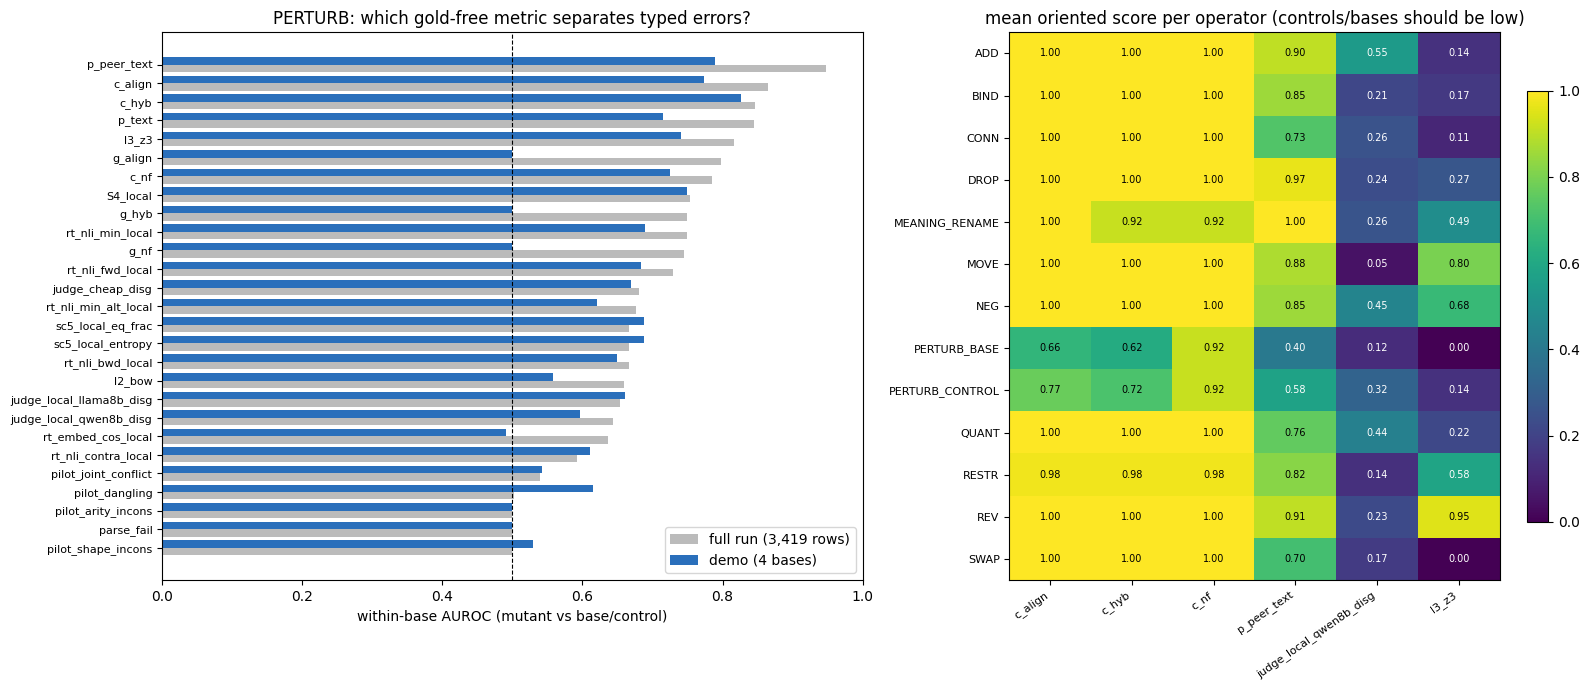

In [12]:
mets = json.loads((RES / "analysis_perturb.json").read_text())["metrics"]
col = {m: {"c_hyb": "c_score_hyb", "g_hyb": "g_score_hyb", "c_nf": "c_score_nf", "c_align": "c_score_align"}.get(m, m) for m in mets}
P = pd.DataFrame([{"base": e["metadata_base_item_id"], "op": e["metadata_operator"] or e["metadata_fold"], "y": int(e["output"] == "ERROR"),
                   **{m: f(e[f"predict_{col[m]}"]) for m in mets}} for e in dsets["PERTURB_suite"]])
full = json.loads((RES / "analysis_perturb.json").read_text())["common_subset"]["metrics"]
rows = []
for m in mets:
    aucs = []
    for b, g in P.groupby("base"):
        g = g.dropna(subset=[m])
        if g.y.nunique() == 2:
            aucs.append(roc_auc_score(g.y, g[m]))
    rows.append({"metric": m, "demo_within_base_auroc": np.mean(aucs) if aucs else np.nan, "n_bases": len(aucs),
                 "n_missing": int(P[m].isna().sum()), "full_run": full.get(m, {}).get("within_base_auroc_all_mutants", np.nan)})
T = pd.DataFrame(rows).sort_values("full_run", ascending=False)
print(f"PERTURB demo rows: {len(P)} ({int(P.y.sum())} mutants, {int((1 - P.y).sum())} controls+bases) over {P.base.nunique()} bases")
print(T.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1.3, 1]})
y = np.arange(len(T))
ax[0].barh(y + 0.2, T.full_run, 0.4, color="#bbbbbb", label="full run (3,419 rows)")
ax[0].barh(y - 0.2, T.demo_within_base_auroc, 0.4, color="#2a6fbb", label=f"demo ({P.base.nunique()} bases)")
ax[0].axvline(0.5, color="k", lw=0.8, ls="--")
ax[0].set_yticks(y); ax[0].set_yticklabels(T.metric, fontsize=8); ax[0].invert_yaxis()
ax[0].set_xlim(0, 1); ax[0].set_xlabel("within-base AUROC (mutant vs base/control)"); ax[0].legend(loc="lower right")
ax[0].set_title("PERTURB: which gold-free metric separates typed errors?")

# per error type: mean oriented score of the three consensus variants + PEER+TEXT (higher = flagged as error)
show = ["c_align", "c_hyb", "c_nf", "p_peer_text", "judge_local_qwen8b_disg", "l3_z3"]
H = P.groupby("op")[show].mean()
im = ax[1].imshow(H.values, cmap="viridis", vmin=0, vmax=1, aspect="auto")
ax[1].set_xticks(range(len(show))); ax[1].set_xticklabels(show, rotation=35, ha="right", fontsize=8)
ax[1].set_yticks(range(len(H))); ax[1].set_yticklabels(H.index, fontsize=8)
for i in range(H.shape[0]):
    for j in range(H.shape[1]):
        v = H.values[i, j]
        ax[1].text(j, i, "" if np.isnan(v) else f"{v:.2f}", ha="center", va="center", fontsize=7, color="w" if v < 0.6 else "k")
ax[1].set_title("mean oriented score per operator (controls/bases should be low)")
fig.colorbar(im, ax=ax[1], fraction=0.04)
plt.tight_layout(); plt.show()

**3. Rewrites and probes (screen pass).** Meaning-preserving rewrites should get about the same consensus score as their base. Probes are synthetic errors and should score high. A RENAME rewrite shows the blind spot that motivated PEER_HYB: ALIGN cannot see past a predicate renamed to a dissimilar name.

In the demo rows, the `RENAME` rewrite `Mammalian(world)` scores **1.00 on ALIGN** but 0.40 on NF/HYB, which is the rename fix working. The `MEANING_RENAME` probe (`Orchestra(x) → Mammal(x)`, a real error) drops from 1.00 on ALIGN to **0.60 on HYB**, which is the over-alignment cost: a name-free map can also accept a rename that changes the meaning.

In [13]:
S = pd.DataFrame([{"fold": e["metadata_fold"], "kind": e.get("metadata_rewrite_family") or e.get("metadata_probe") or e.get("metadata_system", ""),
                   "fol": json.loads(e["input"])["candidate_fol"][:70], "label": e["output"],
                   "c_align": f(e["predict_c_score_align"]), "c_nf": f(e["predict_c_score_nf"]), "c_hyb": f(e["predict_c_score_hyb"])}
                  for d in ("expD_rewrites_screen", "screen_items_and_probes") for e in dsets[d]])
with pd.option_context("display.max_colwidth", 70, "display.width", 220):
    print(S.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("\nConclusion of the original run:", out["metadata"]["selection"]["note"])

        fold             kind                                   fol   label  c_align  c_nf  c_hyb
REWRITE_EXPD           RENAME                      Mammalian(world) CORRECT     1.00  0.40   0.40
REWRITE_EXPD   CONTRAPOSITIVE           ∀x (¬Mammal(x) → ¬Human(x)) CORRECT     0.60  0.60   0.60
REWRITE_EXPD          REORDER       City(boston) ∧ American(boston) CORRECT     0.40  0.40   0.40
REWRITE_EXPD         DEMORGAN  ¬(¬American(boston) ∨ ¬City(boston)) CORRECT     0.40  0.40   0.40
REWRITE_EXPD          REPRINT        ¬(∃x (Digital(x) ∧ Analog(x)))   ERROR     0.00  0.00   0.00
      SCREEN    gpt-3.5-turbo                        Mammal(humans) CORRECT     0.40  0.40   0.40
      SCREEN            gpt-4                         Mammal(human)   ERROR     0.40  0.40   0.40
      SCREEN            gpt-4             ∀x (Human(x) → Mammal(x)) CORRECT     0.60  0.60   0.60
      SCREEN text-davinci-003                        Mammal(humans) CORRECT     0.40  0.40   0.40
SCREEN_PROBE   MEANI